# Exercise 1 — Data Mining vs Machine Learning

What you will learn here:

* distinguish data vs labels
* think about problem formulation
* connect real data → ML type
* understand when ML is needed

In [67]:
# If needed:
# !pip install datasets pandas matplotlib scikit-learn librosa

In [68]:
from datasets import load_dataset
import pandas as pd

Load a small sample from the `ag_news` dataset and is a collection of more than 1 million news articles.

In [69]:
dataset = load_dataset("ag_news", split="train[:200]")

df = dataset.to_pandas()
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### Understand the dataset

In [70]:
df.columns

Index(['text', 'label'], dtype='object')

In [71]:
df[["text", "label"]].head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


## Question
What are the columns?

- Which column is the input data?
- Which column is the label?

First column is input data and second column is label

# Part A — Data Mining: Discover patterns

For this step, you cannot use the `label` column. :)

### Text length

In [72]:
df["text_length"] = df["text"].apply(len)

df[["text", "text_length"]].head()

,text,text_length
0,Wall St. Bears Claw Back Into the Black (Reute...,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,256
4,"Oil prices soar to all-time record, posing new...",234


### Average text length

In [73]:
df["text_length"].mean()

277.225

### Most frequent words

In [74]:
from collections import Counter
import re

all_text = " ".join(df["text"].tolist()).lower()
words = re.findall(r"\b[a-z]{4,}\b", all_text)

word_counts = Counter(words)
word_counts.most_common(20)

[('that', 86),
 ('space', 54),
 ('with', 42),
 ('reuters', 40),
 ('this', 38),
 ('from', 34),
 ('they', 34),
 ('have', 33),
 ('said', 29),
 ('about', 23),
 ('more', 23),
 ('their', 19),
 ('scientists', 19),
 ('what', 19),
 ('would', 19),
 ('over', 18),
 ('after', 18),
 ('could', 18),
 ('time', 17),
 ('company', 17)]

## Reflection

Are we predicting something here?

Or are we discovering patterns already present in the data?

#In this part we are only discovering partterns in the data, frequency of words and average length of text

# Part B — Machine Learning: Use labels

### Inspect labels

In [75]:
df["label"].value_counts()

label
3    122
2     78
Name: count, dtype: int64

### AG News labels are numeric. Add names:
from https://huggingface.co/datasets/sh0416/ag_news 

1: World 2: Sports 3: Business 4: Sci/Tech

In [76]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df["label_name"] = df["label"].map(label_names)
df[["text", "label", "label_name"]].head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Question

What type of ML can we apply for this dataset?

We can apply supervised learning with classification for this dataset

# Part C — Explore a Dataset

In this exercise, you will:

1. Choose a dataset
2. Explore it (Data Mining)
3. Decide whether labels exist
4. Suggest a Machine Learning approach (if applicable)

You should NOT focus on complex models.
Focus on understanding the problem.

## Step 1 — Choose a dataset

* Hugging Face datasets: https://huggingface.co/datasets
* Scikit-learn datasets: https://scikit-learn.org/stable/datasets/toy_dataset.html

Dataset examples:

In [ ]:
dataset = load_dataset("beans", split="train[:100]")

df = dataset.to_pandas()
df.head()

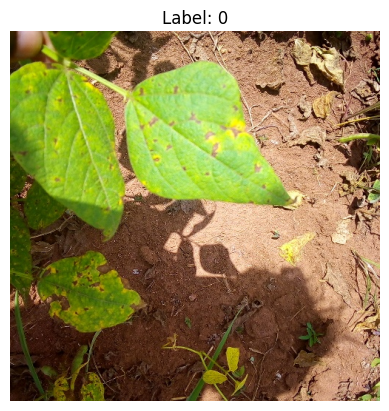

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one example
example = dataset[0]

# Load image
image = example["image"]

# Display
plt.imshow(image)
plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [ ]:
from datasets import load_dataset

dataset = load_dataset("timm/oxford-iiit-pet", split="train[:100]")

df = dataset.to_pandas()
df.head()

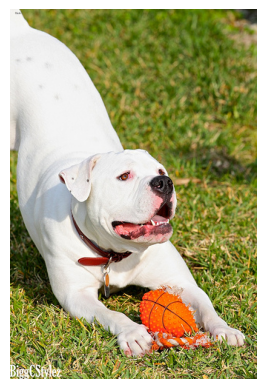

In [12]:
# Get one example
example = dataset[1]

# Load image
image = example["image"]

# Display
plt.imshow(image)
# plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [13]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [80]:
dataset = load_dataset("superb", "ks", split="train[:10]")

df = dataset.to_pandas()
df.head()

,file,audio,label
0,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFFXz.\x00WAVEfmt \x10\x00\x00\x0...,10
1,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF*.\x1e\x00WAVEfmt \x10\x00\x00...,10
2,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF0\xe9\x1d\x00WAVEfmt \x10\x00\...,10
3,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF$L\x1d\x00WAVEfmt \x10\x00\x00...,10
4,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF\xe4\xdc\x1d\x00WAVEfmt \x10\x...,10


In [81]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 50),
    "income": np.random.randint(1000, 5000, 50),
    "spending": np.random.randint(100, 2000, 50)
})

df.head()

,age,income,spending
0,20,2172,857
1,56,4569,1376
2,36,4161,1195
3,48,2529,896
4,23,1930,414


In [90]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:200]")
df = dataset.to_pandas()
df.head()

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : Unrecorded Chronicles (...
4,"The game began development in 2010 , carrying..."


In [92]:
from datasets import load_dataset

dataset = load_dataset("tweet_eval", "sentiment", split="train[:200]")
df = dataset.to_pandas()

df.head()

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


## Step 2 — Explore (Data Mining)

TODO 1: Display a few examples

TODO 2: What type of data is this?
(text, image, tabular)

TODO 3: Find simple patterns

Examples:
- text: most frequent words
- tabular: average values
- images: visualize samples
etc.

In [16]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


This is tabular dataset.
Simple parttern: Type of wines

## Step 3 — Think about labels

### Questions

1. Does this dataset contain labels?
2. If yes:
   - What are they?
3. If no:
   - What could we try to discover?

This dataset contain label and we try to discover the class of wine which is class 0, class 1 and class 2.

## Step 4 — Decide the type of ML

### Identify the problem

- Is this:
  - Data Mining?
  - Supervised Learning?
  - Unsupervised Learning?
  - Reinforcement Learning?

Explain your reasoning.

Since the dataset contains labels, this dataset uses supervised learning.

## Step 5 — Suggest a task

### Your task

Propose ONE task:

- What is the input (X)?
- What is the output (y)? (if any)
- What is the goal?

Examples:
- classify articles
- cluster customers
- extract entities

Input X: The substances in wine in numerical

Output Y: Class of wine

The goal: Train a model to classifies type of wines in 3 classes